In [2]:
%matplotlib inline
import numpy as np
import xarray as xr
from datetime import datetime, timedelta
import cmocean
from matplotlib import pyplot as plt, rc
rc('animation', html='html5')
import os

# from scipy.stats import pearsonr

In [3]:
from scipy.stats import pearsonr

In [4]:
M_path = '/home/jvalenti/MOAD/'
coords = xr.open_dataset(M_path+'grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset(M_path+'grid2/mesh_mask202108_TDV.nc')
lon = coords.nav_lon
x= np.linspace(0,lon.shape[1],lon.shape[1])
y = np.linspace(0,lon.shape[0],lon.shape[0])
X,Y = np.meshgrid(x,y)

/home/jvalenti/MOAD/analysis-jose/.pixi/envs/shem/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'erddapy' loading failed:
HTTPSConnectionPool(host='raw.githubusercontent.com', port=443): Max retries exceeded with url: /IrishMarineInstitute/awesome-erddap/master/erddaps.json (Caused by NewConnectionError("HTTPSConnection(host='raw.githubusercontent.com', port=443): Failed to establish a new connection: [Errno 101] Network is unreachable"))
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [5]:
jjii = xr.open_dataset('~/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [6]:
def make_filename(path_run,start,day, var='prod_T', res='d'):
    """Construct path prefix for local SHEM results given date object and paths dict
    """
    date  =  (start + timedelta(days=day))
    folder = date.strftime("%d%b%y").lower()
    prefix = os.path.join(path_run, f'{folder}/')
    fname = []
    for file in os.listdir(prefix):
        if (var in file) and ('_1'+res) in file:
            fname.append(file)
    if len(fname)>1:
        print('more than one file found') 
    
    return os.path.join(f'{folder}/', fname[0])


In [7]:
path_run = '/home/jvalenti/scratch/run_SHEM/long_run/' 
#path_run = '/home/jvalenti/projects/rrg-allen/SalishSea/nowcast-green.202111/'
day = 1
start = datetime(2023,1,1)
make_filename(path_run,start,day, var='biol_T', res='h')

'02jan23/SHEM_1h_20230102-20230102_biol_T.nc'

In [8]:
Ox = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).dissolved_oxygen
diat = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).diatoms
NO3 = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).nitrate
flag = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).flagellates
hbac = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).heterotrophic_bacteria
DOM = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).dissolved_organic_nitrogen
POM = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).particulate_organic_nitrogen

In [9]:
#(imin,imax,jmin,jmax)
regions = {'JdF':(25,125,250,400),'NSoG':(100,225,650,720),'CSoG':(180,300,450,550),'PS':(200,300,25,200)}
colors_reg={'JdF':'tab:blue','NSoG':'tab:orange','CSoG':'tab:green','PS':'tab:red'}
def mark_region(region,color = 'tab:blue'):
    coords = regions[region]
    x = [coords[0], coords[1], coords[1], coords[0], coords[0]]
    y = [coords[2], coords[2], coords[3], coords[3], coords[2]]
    plt.plot(x, y, color=color,label=region)


/home/jvalenti/MOAD/analysis-jose/.pixi/envs/shem/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


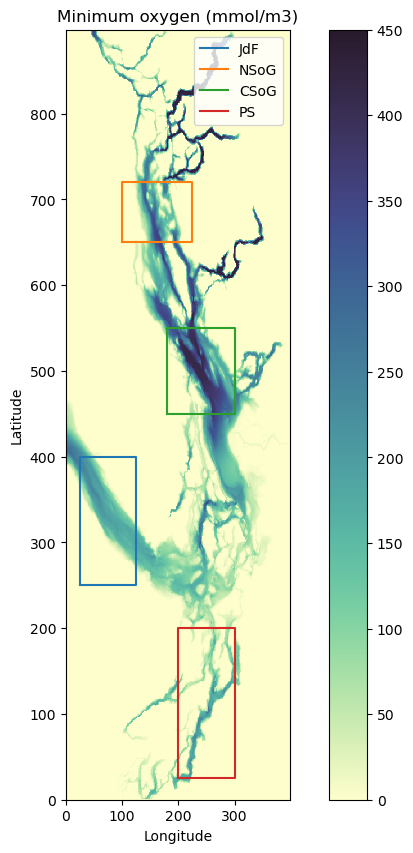

In [10]:
colors=['tab:blue','tab:orange','tab:green','tab:red']
fig, ax = plt.subplots(figsize=(10,10))
plt.pcolormesh(mask.totaldepth,cmap= cmocean.cm.deep, vmin=0, vmax=450)
plt.colorbar()
f = 1.0/np.cos(49*np.pi/180)
for i,region in enumerate(regions.keys()):
    mark_region(region,color=colors[i])
plt.legend()
plt.gca().set_aspect(f)
plt.title('Minimum oxygen (mmol/m3)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [11]:
vol = mask.volume.where(mask.tmask == 1).sel(t=0)

In [13]:
mean_profiles = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_full_2year.npy')
mean_profiles_reg = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_regions_2year.npy')

Len = mean_profiles.shape[0]

region = 'JdF'
ii = 0
weighted_means = np.full((len(regions.keys())+1,Len), np.nan)

def weighted_mean_concentration(mean_profile,region=None,regions=None):
    if region is not None:
        x0, x1, y0, y1 = regions[region]
        vol_r = vol.isel(y=slice(y0, y1), x=slice(x0, x1))
    else:
        region = 'full domain'
        vol_r = vol

    vol_r = vol_r.sum(axis=(1,2))
    weighted_mean = np.average(mean_profile,axis=1,weights=vol_r)
    return weighted_mean

for ii, region in enumerate(regions.keys()):
    weighted_means[ii,:] = weighted_mean_concentration(mean_profiles_reg[ii,:,:], region=region, regions=regions)


weighted_means_full = weighted_mean_concentration(mean_profiles)

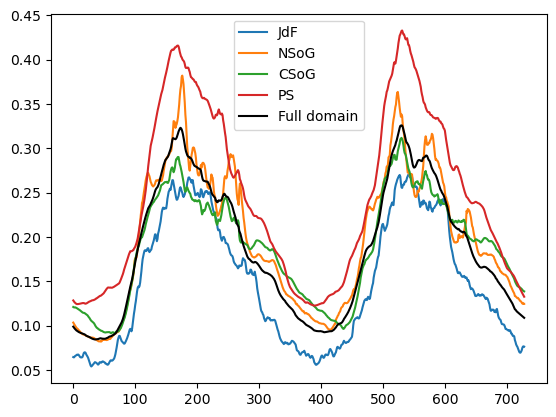

In [14]:
for ii, region in enumerate(regions.keys()):
    plt.plot(weighted_means[ii,:].T,c=colors_reg[region],label=region)
plt.plot(weighted_means_full,c='k',label='Full domain')
plt.legend()

In [15]:
mean_profiles = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_full_2year.npy')
mean_profiles_reg = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_regions_2year.npy')

In [16]:
mean_profiles_reg_TS = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_ST_regions_2year.npy')

In [17]:
T = mean_profiles_reg_TS[0,:,:,:]
S = mean_profiles_reg_TS[1,:,:,:]

In [18]:
r, p = pearsonr(T[i,:,:].flatten(),mean_profiles_reg[i,:,:].flatten())

Text(0.5, 1.0, 'Salinity vs Heterotrophic bacteria')

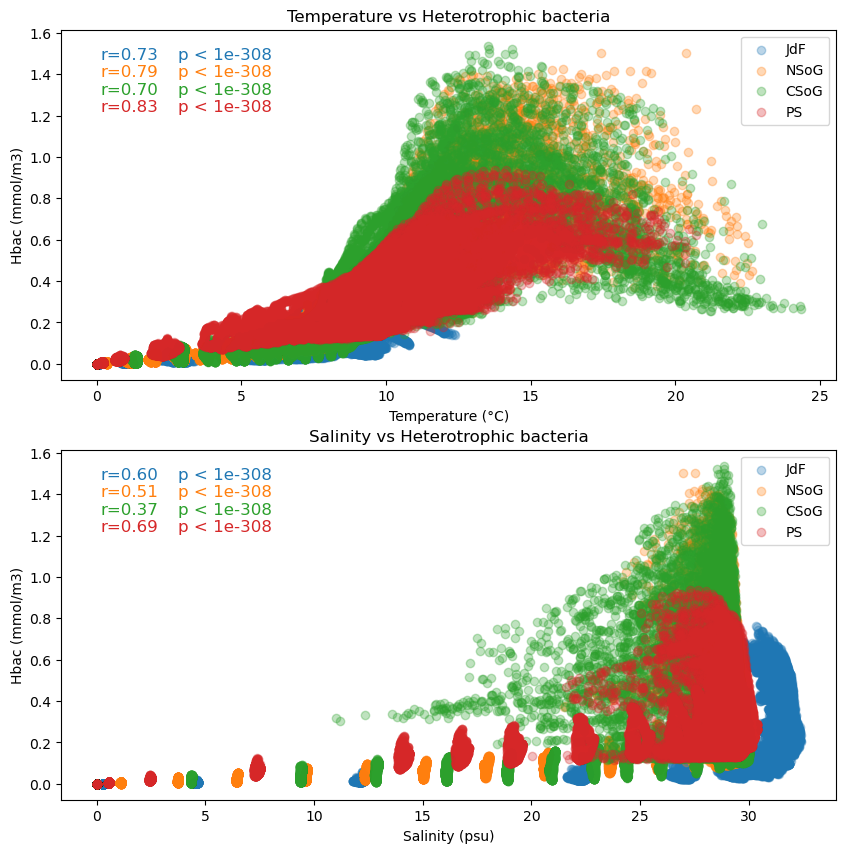

In [23]:
fig, axs = plt.subplots(2,1,figsize=(10,10))
for i,region in enumerate(regions.keys()):
    axs[0].scatter(T[i,:,:].flatten(),mean_profiles_reg[i,:,:].flatten(),alpha=0.3,color= colors_reg[region],label=region)
    r, p = pearsonr(T[i,:,:].flatten(),mean_profiles_reg[i,:,:].flatten())
    if p == 0:
        p_label = "p < 1e-308"
    else:
        p_label = f"p = {p:.1e}"
    axs[0].annotate(f'r={r:.2f}', xy=(0.05, 0.95- i*0.05), xycoords='axes fraction', fontsize=12, verticalalignment='top',color=colors_reg[region])
    axs[0].annotate(f'{p_label}', xy=(0.15, 0.95- i*0.05), xycoords='axes fraction', fontsize=12, verticalalignment='top',color=colors_reg[region])
axs[0].legend()
axs[0].set_xlabel('Temperature (°C)')
axs[0].set_ylabel('Hbac (mmol/m3)')
axs[0].set_title('Temperature vs Heterotrophic bacteria')

for i,region in enumerate(regions.keys()):
    axs[1].scatter(S[i,:,:].flatten(),mean_profiles_reg[i,:,:].flatten(),alpha=0.3,color= colors_reg[region],label=region)
    r, p = pearsonr(S[i,:,:].flatten(),mean_profiles_reg[i,:,:].flatten())
    if p == 0:
        p_label = "p < 1e-308"
    else:
        p_label = f"p = {p:.1e}"
    axs[1].annotate(f'r={r:.2f}', xy=(0.05, 0.95- i*0.05), xycoords='axes fraction', fontsize=12, verticalalignment='top',color=colors_reg[region])
    axs[1].annotate(f'{p_label}', xy=(0.15, 0.95- i*0.05), xycoords='axes fraction', fontsize=12, verticalalignment='top',color=colors_reg[region])
axs[1].legend()
axs[1].set_xlabel('Salinity (psu)')
axs[1].set_ylabel('Hbac (mmol/m3)')
axs[1].set_title('Salinity vs Heterotrophic bacteria')